# PX4 Phase 1 Rate Dynamics PINN Training v12 Altitude Residual Diagnostic

v12 keeps the v10 relaxed direct-dynamics style, but handles altitude as:

```text
kinematic_dh = -0.5 * (vel_down + vel_down_next) * dt
learned_dh_residual = small bounded correction
final_dh = kinematic_dh + learned_dh_residual
```

This tests the hypothesis from v11: pure kinematic altitude reduces bias, but PX4/Gazebo telemetry and estimator/sampling effects still need a weak learned correction.

The notebook also adds data diagnostics for hover altitude drift. If hover data is falling even with near-zero rate setpoints, the issue may be the data collection regime: offboard rate/thrust setpoints do not use PX4 altitude hold, so hover thrust bias appears directly as altitude drift.


In [1]:
# Colab setup
from pathlib import Path
import json
import math
import os
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

try:
    from google.colab import drive
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    drive.mount('/content/drive')

SEED = 7
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
print('torch:', torch.__version__)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
device: cuda
torch: 2.10.0+cu128


In [2]:
# Dataset path
DATASET_DIR = ''

def find_latest_dataset_dir():
    import glob
    patterns = [
        '/content/drive/MyDrive/**/px4_phase1_rate_dynamics_dataset_v4_filtered_imu_aux_*',
        '/content/**/px4_phase1_rate_dynamics_dataset_v4_filtered_imu_aux_*',
        './px4_phase1_rate_dynamics_dataset_v4_filtered_imu_aux_*',
        '/content/drive/MyDrive/**/px4_phase1_rate_dynamics_dataset_v3_imu_aux_*',
    ]
    matches=[]
    for pat in patterns:
        matches.extend(glob.glob(pat, recursive=True))
    matches=sorted(set(matches))
    matches=[Path(m) for m in matches if (Path(m)/'train.csv').exists()]
    if not matches:
        raise FileNotFoundError('No v4/v3 processed dataset found. Set DATASET_DIR manually.')
    return matches[-1]

DATASET_PATH = Path(DATASET_DIR) if DATASET_DIR else find_latest_dataset_dir()
print('DATASET_PATH:', DATASET_PATH)
print('files:', sorted([p.name for p in DATASET_PATH.iterdir()])[:20])


DATASET_PATH: /content/drive/MyDrive/px4_datasets/processed/px4_phase1_rate_dynamics_dataset_v4_filtered_imu_aux_20260508_175455
files: ['all_samples.csv', 'dataset_summary.csv', 'filter_report.csv', 'metadata.json', 'source_summary.csv', 'test.csv', 'train.csv', 'val.csv']


In [3]:
# Load data and create nominal/stress split
base_train = pd.read_csv(DATASET_PATH / 'train.csv')
base_val = pd.read_csv(DATASET_PATH / 'val.csv')
base_test = pd.read_csv(DATASET_PATH / 'test.csv')
all_df = pd.read_csv(DATASET_PATH / 'all_samples.csv') if (DATASET_PATH / 'all_samples.csv').exists() else pd.concat([base_train, base_val, base_test], ignore_index=True)

metadata = {}
if (DATASET_PATH / 'metadata.json').exists():
    metadata = json.loads((DATASET_PATH / 'metadata.json').read_text())

state_cols = metadata.get('state_cols') or [c.removeprefix('dx_') for c in all_df.columns if c.startswith('dx_')]
action_cols = metadata.get('action_cols') or [c.removeprefix('u_') for c in all_df.columns if c.startswith('u_')]
feature_cols = [f'x_{c}' for c in state_cols] + [f'u_{c}' for c in action_cols] + [f'prev_u_{c}' for c in action_cols] + [f'du_{c}' for c in action_cols] + ['dt_s']
target_cols = [f'dx_{c}' for c in state_cols]
# v12 learns all dx except altitude directly, plus a small altitude residual.
learned_target_cols = [c for c in target_cols if c != 'dx_relative_altitude_m']
next_cols = [f'x_next_{c}' for c in state_cols]
aux_cols = [
    'aux_derived_accel_north_m_s2',
    'aux_derived_accel_east_m_s2',
    'aux_derived_accel_down_m_s2',
    'aux_derived_roll_accel_rad_s2',
    'aux_derived_pitch_accel_rad_s2',
    'aux_derived_yaw_accel_rad_s2',
]
missing = [c for c in feature_cols + target_cols + next_cols + aux_cols if c not in all_df.columns]
if missing:
    raise ValueError(f'Missing columns: {missing}')

needed = feature_cols + target_cols + next_cols + aux_cols
all_df = all_df[np.isfinite(all_df[needed].to_numpy(np.float32)).all(axis=1)].copy()

STRESS_SCENARIOS = ['N11_mixed_sequence']
VAL_FRACTION = 0.14
TEST_FRACTION = 0.14
MIN_GROUP_FOR_SPLIT = 30

stress_test_df = all_df[all_df['scenario'].isin(STRESS_SCENARIOS)].copy() if 'scenario' in all_df.columns else all_df.iloc[0:0].copy()
nominal_df = all_df[~all_df['scenario'].isin(STRESS_SCENARIOS)].copy() if 'scenario' in all_df.columns else all_df.copy()

rng = np.random.default_rng(SEED)
train_idx=[]; val_idx=[]; test_idx=[]
group_cols = [c for c in ['source_run', 'scenario'] if c in nominal_df.columns]
if group_cols:
    for _, group in nominal_df.groupby(group_cols, sort=False):
        idx = group.index.to_numpy().copy(); rng.shuffle(idx)
        if len(idx) < MIN_GROUP_FOR_SPLIT:
            train_idx.extend(idx.tolist()); continue
        n_test = max(1, int(round(len(idx) * TEST_FRACTION)))
        n_val = max(1, int(round(len(idx) * VAL_FRACTION)))
        test_idx.extend(idx[:n_test].tolist())
        val_idx.extend(idx[n_test:n_test+n_val].tolist())
        train_idx.extend(idx[n_test+n_val:].tolist())
else:
    idx = nominal_df.index.to_numpy().copy(); rng.shuffle(idx)
    n_test=int(round(len(idx)*TEST_FRACTION)); n_val=int(round(len(idx)*VAL_FRACTION))
    test_idx=idx[:n_test].tolist(); val_idx=idx[n_test:n_test+n_val].tolist(); train_idx=idx[n_test+n_val:].tolist()

train_df = nominal_df.loc[sorted(train_idx)].copy()
val_df = nominal_df.loc[sorted(val_idx)].copy()
test_df = nominal_df.loc[sorted(test_idx)].copy()

print('train/val/test/stress rows:', len(train_df), len(val_df), len(test_df), len(stress_test_df))
print('learned_target_cols:', learned_target_cols)
if 'scenario' in all_df.columns:
    split_view = pd.concat([train_df.assign(split_view='train'), val_df.assign(split_view='val'), test_df.assign(split_view='test'), stress_test_df.assign(split_view='stress')])
    display(split_view.groupby(['split_view','scenario']).size().to_frame('rows').reset_index())


train/val/test/stress rows: 11368 2217 2217 1445
learned_target_cols: ['dx_vel_north_m_s', 'dx_vel_east_m_s', 'dx_vel_down_m_s', 'dx_roll_deg', 'dx_pitch_deg', 'dx_yaw_deg', 'dx_roll_rate_rad_s', 'dx_pitch_rate_rad_s', 'dx_yaw_rate_rad_s']


,split_view,scenario,rows
0,stress,N11_mixed_sequence,1445
1,test,N00_hover_hold_0p5192,168
2,test,N01_pitch_rate_doublet_5dps,196
3,test,N02_pitch_rate_doublet_10dps,191
4,test,N03_roll_rate_doublet_5dps,185
5,test,N04_roll_rate_doublet_10dps,196
6,test,N05_yaw_rate_doublet_10dps,196
7,test,N06_yaw_rate_doublet_20dps,293
8,test,N07_thrust_step_pm010,196
9,test,N08_thrust_step_pm020,196


In [4]:
# Data diagnostics: hover altitude drift and kinematic consistency
hover = all_df[all_df['scenario'].eq('N00_hover_hold_0p5192')].copy() if 'scenario' in all_df.columns else all_df.iloc[0:0].copy()

def summarize_hover_groups(df):
    if len(df) == 0:
        return pd.DataFrame()
    rows=[]
    group_cols=[c for c in ['source_run','scenario'] if c in df.columns]
    for key,g in df.sort_values('time_s').groupby(group_cols, sort=False):
        if len(g)<5:
            continue
        dt = g['dt_s'].to_numpy(float)
        vel_down = g['x_vel_down_m_s'].to_numpy(float)
        dx_vd = g['dx_vel_down_m_s'].to_numpy(float)
        dh_kin = -0.5*(vel_down + vel_down + dx_vd)*dt
        dh_true = g['dx_relative_altitude_m'].to_numpy(float)
        rows.append({
            'group': str(key),
            'rows': len(g),
            'duration_s': float(g['time_s'].max() - g['time_s'].min()),
            'alt_start_m': float(g['x_relative_altitude_m'].iloc[0]),
            'alt_end_next_m': float(g['x_next_relative_altitude_m'].iloc[-1]),
            'alt_drift_m': float(g['x_next_relative_altitude_m'].iloc[-1] - g['x_relative_altitude_m'].iloc[0]),
            'mean_ref_thrust': float(g['u_ref_thrust'].mean()) if 'u_ref_thrust' in g.columns else np.nan,
            'mean_vel_down_m_s': float(g['x_vel_down_m_s'].mean()),
            'mean_dx_alt_m': float(np.mean(dh_true)),
            'mean_kin_dx_alt_m': float(np.mean(dh_kin)),
            'kin_alt_resid_rmse_m': float(np.sqrt(np.mean((dh_true-dh_kin)**2))),
        })
    return pd.DataFrame(rows)

hover_diag = summarize_hover_groups(hover)
print('Hover diagnostics. Negative alt_drift_m means falling in relative altitude.')
display(hover_diag)
if len(hover_diag):
    display(hover_diag[['alt_drift_m','mean_ref_thrust','mean_vel_down_m_s','kin_alt_resid_rmse_m']].describe())

# Overall kinematic residual by scenario. If this residual is large, altitude telemetry and vel_down integration disagree.
rows=[]
for scenario,g in all_df.groupby('scenario') if 'scenario' in all_df.columns else []:
    dt=g['dt_s'].to_numpy(float)
    vd=g['x_vel_down_m_s'].to_numpy(float)
    dvd=g['dx_vel_down_m_s'].to_numpy(float)
    dh_kin=-0.5*(vd+vd+dvd)*dt
    dh_true=g['dx_relative_altitude_m'].to_numpy(float)
    rows.append({
        'scenario': scenario,
        'rows': len(g),
        'true_dh_mean_m': float(np.mean(dh_true)),
        'kin_dh_mean_m': float(np.mean(dh_kin)),
        'kin_resid_rmse_m': float(np.sqrt(np.mean((dh_true-dh_kin)**2))),
        'true_dh_rmse_m': float(np.sqrt(np.mean(dh_true**2))),
    })
kin_diag=pd.DataFrame(rows).sort_values('kin_resid_rmse_m', ascending=False)
print('Altitude kinematic consistency by scenario:')
display(kin_diag)


Hover diagnostics. Negative alt_drift_m means falling in relative altitude.


,group,rows,duration_s,alt_start_m,alt_end_next_m,alt_drift_m,mean_ref_thrust,mean_vel_down_m_s,mean_dx_alt_m,mean_kin_dx_alt_m,kin_alt_resid_rmse_m
0,('px4_phase1_standard_vtol_nominal_rate_datase...,598,29.851542,24.989000,15.831000,-9.158,0.5192,0.333562,-0.015314,-0.016709,0.009131
1,('px4_phase1_standard_vtol_nominal_rate_datase...,597,29.852331,24.874001,16.464001,-8.410,0.5192,0.237052,-0.012462,-0.011869,0.003004


,alt_drift_m,mean_ref_thrust,mean_vel_down_m_s,kin_alt_resid_rmse_m
count,2.000000,2.000000e+00,2.000000,2.000000
mean,-8.784000,5.192000e-01,0.285307,0.006068
std,0.528916,1.110223e-16,0.068243,0.004332
min,-9.158000,5.192000e-01,0.237052,0.003004
25%,-8.971000,5.192000e-01,0.261179,0.004536
50%,-8.784000,5.192000e-01,0.285307,0.006068
75%,-8.597000,5.192000e-01,0.309434,0.007600
max,-8.410000,5.192000e-01,0.333562,0.009131


Altitude kinematic consistency by scenario:


,scenario,rows,true_dh_mean_m,kin_dh_mean_m,kin_resid_rmse_m,true_dh_rmse_m
10,N10_roll_yaw_coupled,1515,-0.009558,-0.010469,0.008656,0.014184
5,N05_yaw_rate_doublet_10dps,1396,-0.002448,-0.006870,0.007799,0.007125
6,N06_yaw_rate_doublet_20dps,2091,-0.000943,-0.000333,0.007608,0.006574
7,N07_thrust_step_pm010,1394,-0.017200,-0.013958,0.007012,0.024107
0,N00_hover_hold_0p5192,1195,-0.013890,-0.014291,0.006800,0.018487
9,N09_pitch_thrust_coupled,1345,-0.019574,-0.018785,0.006307,0.024561
2,N02_pitch_rate_doublet_10dps,1368,-0.019888,-0.018288,0.006066,0.023909
3,N03_roll_rate_doublet_5dps,1316,-0.019090,-0.016374,0.005739,0.023068
8,N08_thrust_step_pm020,1394,-0.013618,-0.011739,0.005735,0.021896
4,N04_roll_rate_doublet_10dps,1394,-0.019049,-0.020690,0.005661,0.022457


In [5]:
# Scalers and dataloaders
class StandardScaler:
    def __init__(self, mean, std):
        self.mean=np.asarray(mean,dtype=np.float32)
        self.std=np.asarray(std,dtype=np.float32)
        self.std=np.where(self.std<1e-8,1.0,self.std)
    @classmethod
    def fit(cls, arr): return cls(np.nanmean(arr,axis=0), np.nanstd(arr,axis=0))
    def transform(self, arr): return (np.asarray(arr,dtype=np.float32)-self.mean)/self.std
    def inverse_transform(self, arr): return np.asarray(arr,dtype=np.float32)*self.std+self.mean
    def to_dict(self, columns): return {'columns':list(columns),'mean':self.mean.tolist(),'std':self.std.tolist()}

X_train_raw=train_df[feature_cols].to_numpy(np.float32); Y_train_raw=train_df[learned_target_cols].to_numpy(np.float32); Yfull_train_raw=train_df[target_cols].to_numpy(np.float32); A_train_raw=train_df[aux_cols].to_numpy(np.float32)
X_val_raw=val_df[feature_cols].to_numpy(np.float32); Y_val_raw=val_df[learned_target_cols].to_numpy(np.float32); Yfull_val_raw=val_df[target_cols].to_numpy(np.float32); A_val_raw=val_df[aux_cols].to_numpy(np.float32)
X_test_raw=test_df[feature_cols].to_numpy(np.float32); Y_test_raw=test_df[learned_target_cols].to_numpy(np.float32); Yfull_test_raw=test_df[target_cols].to_numpy(np.float32); A_test_raw=test_df[aux_cols].to_numpy(np.float32)

x_scaler=StandardScaler.fit(X_train_raw)
y_scaler=StandardScaler.fit(Y_train_raw)
yfull_scaler=StandardScaler.fit(Yfull_train_raw)
a_scaler=StandardScaler.fit(A_train_raw)

X_train=x_scaler.transform(X_train_raw); Y_train=y_scaler.transform(Y_train_raw); Yfull_train=yfull_scaler.transform(Yfull_train_raw); A_train=a_scaler.transform(A_train_raw)
X_val=x_scaler.transform(X_val_raw); Y_val=y_scaler.transform(Y_val_raw); Yfull_val=yfull_scaler.transform(Yfull_val_raw); A_val=a_scaler.transform(A_val_raw)
X_test=x_scaler.transform(X_test_raw); Y_test=y_scaler.transform(Y_test_raw); Yfull_test=yfull_scaler.transform(Yfull_test_raw); A_test=a_scaler.transform(A_test_raw)

BATCH_SIZE=1024
train_loader=DataLoader(TensorDataset(torch.tensor(X_train), torch.tensor(Y_train), torch.tensor(Yfull_train), torch.tensor(A_train)), batch_size=BATCH_SIZE, shuffle=True)
val_loader=DataLoader(TensorDataset(torch.tensor(X_val), torch.tensor(Y_val), torch.tensor(Yfull_val), torch.tensor(A_val)), batch_size=BATCH_SIZE, shuffle=False)

x_mean_t=torch.tensor(x_scaler.mean,dtype=torch.float32,device=device); x_std_t=torch.tensor(x_scaler.std,dtype=torch.float32,device=device)
y_mean_t=torch.tensor(y_scaler.mean,dtype=torch.float32,device=device); y_std_t=torch.tensor(y_scaler.std,dtype=torch.float32,device=device)
yfull_mean_t=torch.tensor(yfull_scaler.mean,dtype=torch.float32,device=device); yfull_std_t=torch.tensor(yfull_scaler.std,dtype=torch.float32,device=device)
a_mean_t=torch.tensor(a_scaler.mean,dtype=torch.float32,device=device); a_std_t=torch.tensor(a_scaler.std,dtype=torch.float32,device=device)
feature_index={c:i for i,c in enumerate(feature_cols)}; learned_target_index={c:i for i,c in enumerate(learned_target_cols)}; target_index={c:i for i,c in enumerate(target_cols)}; aux_index={c:i for i,c in enumerate(aux_cols)}
print('batches:', len(train_loader), len(val_loader))


batches: 12 3


In [6]:
# Model: learned dx except altitude + bounded altitude residual + aux head
class AltResidualDxAuxMLP(nn.Module):
    def __init__(self, n_in, n_dx, n_aux, hidden=512, depth=5, dropout=0.02):
        super().__init__()
        layers=[]; last=n_in
        for _ in range(depth):
            layers += [nn.Linear(last,hidden), nn.SiLU(), nn.LayerNorm(hidden)]
            if dropout>0: layers.append(nn.Dropout(dropout))
            last=hidden
        self.trunk=nn.Sequential(*layers)
        self.dx_head=nn.Linear(last,n_dx)
        self.alt_residual_head=nn.Linear(last,1)
        self.aux_head=nn.Linear(last,n_aux)
    def forward(self,x):
        z=self.trunk(x)
        return self.dx_head(z), self.alt_residual_head(z).squeeze(-1), self.aux_head(z)

MODEL_CONFIG=dict(hidden=512, depth=5, dropout=0.02)
model=AltResidualDxAuxMLP(len(feature_cols), len(learned_target_cols), len(aux_cols), **MODEL_CONFIG).to(device)
print(model)
print('parameters:', sum(p.numel() for p in model.parameters()))


AltResidualDxAuxMLP(
  (trunk): Sequential(
    (0): Linear(in_features=23, out_features=512, bias=True)
    (1): SiLU()
    (2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (3): Dropout(p=0.02, inplace=False)
    (4): Linear(in_features=512, out_features=512, bias=True)
    (5): SiLU()
    (6): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (7): Dropout(p=0.02, inplace=False)
    (8): Linear(in_features=512, out_features=512, bias=True)
    (9): SiLU()
    (10): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (11): Dropout(p=0.02, inplace=False)
    (12): Linear(in_features=512, out_features=512, bias=True)
    (13): SiLU()
    (14): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (15): Dropout(p=0.02, inplace=False)
    (16): Linear(in_features=512, out_features=512, bias=True)
    (17): SiLU()
    (18): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (19): Dropout(p=0.02, inplace=False)
  )
  (dx_head): Linear(in_features=512, o

In [7]:
# Losses and altitude residual assembly
EPOCHS=900
LR=1e-3
WEIGHT_DECAY=2e-5
PATIENCE=130
GRAD_CLIP=2.0

DATA_WEIGHT=1.0
FULL_DX_WEIGHT=0.25
AUX_WEIGHT=0.08
EULER_KIN_WEIGHT=0.030
AUX_CONSISTENCY_WEIGHT=0.025
ALT_RESIDUAL_REG_WEIGHT=0.035
EULER_RESID_SCALE_RAD=np.deg2rad(1.0)
ALT_RESIDUAL_LIMIT_M=0.025

LEARNED_TARGET_DATA_WEIGHTS={'dx_vel_down_m_s':1.15,'dx_yaw_deg':1.10,'dx_yaw_rate_rad_s':1.08}
FULL_TARGET_WEIGHTS={'dx_relative_altitude_m':1.35,'dx_vel_down_m_s':1.10,'dx_yaw_deg':1.05}
AUX_DATA_WEIGHTS={'aux_derived_accel_down_m_s2':1.10,'aux_derived_yaw_accel_rad_s2':1.10}

learned_weight_vec=torch.ones(len(learned_target_cols),dtype=torch.float32,device=device)
for name,w in LEARNED_TARGET_DATA_WEIGHTS.items():
    if name in learned_target_index: learned_weight_vec[learned_target_index[name]]=float(w)
full_weight_vec=torch.ones(len(target_cols),dtype=torch.float32,device=device)
for name,w in FULL_TARGET_WEIGHTS.items():
    if name in target_index: full_weight_vec[target_index[name]]=float(w)
aux_weight_vec=torch.ones(len(aux_cols),dtype=torch.float32,device=device)
for name,w in AUX_DATA_WEIGHTS.items():
    if name in aux_index: aux_weight_vec[aux_index[name]]=float(w)

optimizer=torch.optim.AdamW(model.parameters(),lr=LR,weight_decay=WEIGHT_DECAY)
scheduler=torch.optim.lr_scheduler.CosineAnnealingLR(optimizer,T_max=EPOCHS,eta_min=1e-5)

def smooth_l1_weighted(pred,target,weight_vec,beta=0.5):
    err=pred-target; ae=torch.abs(err)
    loss=torch.where(ae<beta,0.5*err**2/beta,ae-0.5*beta)
    return torch.mean(loss*weight_vec[None,:])

def wrap_rad(a): return torch.atan2(torch.sin(a), torch.cos(a))
def raw_feature(xb,name):
    i=feature_index[name]; return xb[:,i]*x_std_t[i]+x_mean_t[i]
def raw_learned_dx(pred_scaled,name):
    i=learned_target_index[name]; return pred_scaled[:,i]*y_std_t[i]+y_mean_t[i]

def assemble_full_dx_raw(xb,pred_learned_scaled,alt_resid_raw):
    dt=raw_feature(xb,'dt_s').clamp_min(1e-4)
    vd=raw_feature(xb,'x_vel_down_m_s')
    dvd=raw_learned_dx(pred_learned_scaled,'dx_vel_down_m_s')
    dh_kin=-0.5*(vd+vd+dvd)*dt
    dh_resid=torch.tanh(alt_resid_raw)*ALT_RESIDUAL_LIMIT_M
    dh=dh_kin+dh_resid
    cols=[]
    for name in target_cols:
        if name=='dx_relative_altitude_m': cols.append(dh)
        else: cols.append(raw_learned_dx(pred_learned_scaled,name))
    return torch.stack(cols,dim=1), dh_resid

def full_dx_scaled_from_raw(full_raw):
    return (full_raw-yfull_mean_t[None,:])/yfull_std_t[None,:]

def euler_loss(xb,full_dx_raw):
    dt=raw_feature(xb,'dt_s').clamp_min(1e-4)
    phi=torch.deg2rad(raw_feature(xb,'x_roll_deg'))
    theta=torch.deg2rad(raw_feature(xb,'x_pitch_deg')).clamp(-1.2,1.2)
    p=raw_feature(xb,'x_roll_rate_rad_s'); q=raw_feature(xb,'x_pitch_rate_rad_s'); r=raw_feature(xb,'x_yaw_rate_rad_s')
    tan_theta=torch.tan(theta); cos_theta=torch.cos(theta).clamp_min(0.2); sin_phi=torch.sin(phi); cos_phi=torch.cos(phi)
    phi_dot=p+tan_theta*(q*sin_phi+r*cos_phi)
    theta_dot=q*cos_phi-r*sin_phi
    psi_dot=(q*sin_phi+r*cos_phi)/cos_theta
    dphi=torch.deg2rad(full_dx_raw[:,target_index['dx_roll_deg']])
    dtheta=torch.deg2rad(full_dx_raw[:,target_index['dx_pitch_deg']])
    dpsi=torch.deg2rad(full_dx_raw[:,target_index['dx_yaw_deg']])
    e=torch.stack([(dphi-phi_dot*dt)/EULER_RESID_SCALE_RAD,(dtheta-theta_dot*dt)/EULER_RESID_SCALE_RAD,wrap_rad(dpsi-psi_dot*dt)/EULER_RESID_SCALE_RAD],dim=1)
    return torch.mean(e**2)

def aux_consistency_loss(xb,pred_learned_scaled,aux_scaled_true):
    dt=raw_feature(xb,'dt_s').clamp_min(1e-4)
    losses=[]
    pairs=[('dx_vel_north_m_s','aux_derived_accel_north_m_s2'),('dx_vel_east_m_s','aux_derived_accel_east_m_s2'),('dx_vel_down_m_s','aux_derived_accel_down_m_s2'),('dx_roll_rate_rad_s','aux_derived_roll_accel_rad_s2'),('dx_pitch_rate_rad_s','aux_derived_pitch_accel_rad_s2'),('dx_yaw_rate_rad_s','aux_derived_yaw_accel_rad_s2')]
    for dx_name,aux_name in pairs:
        if dx_name not in learned_target_index or aux_name not in aux_index: continue
        raw_est=raw_learned_dx(pred_learned_scaled,dx_name)/dt
        j=aux_index[aux_name]
        est_scaled=(raw_est-a_mean_t[j])/a_std_t[j]
        losses.append(torch.mean((est_scaled-aux_scaled_true[:,j])**2))
    return torch.stack(losses).mean() if losses else torch.tensor(0.0,device=device)


epoch 0001 train=0.5817 val=0.2181 data=0.1437 full=0.1628 aux=0.1948 alt_resid=0.0552 best=0.2181@1
epoch 0025 train=0.1350 val=0.1298 data=0.0860 full=0.0900 aux=0.1197 alt_resid=0.0054 best=0.1298@25
epoch 0050 train=0.1274 val=0.1274 data=0.0844 full=0.0864 aux=0.1179 alt_resid=0.0102 best=0.1264@46
epoch 0075 train=0.1253 val=0.1248 data=0.0834 full=0.0849 aux=0.1157 alt_resid=0.0106 best=0.1248@75
epoch 0100 train=0.1206 val=0.1239 data=0.0818 full=0.0830 aux=0.1163 alt_resid=0.0125 best=0.1236@77
epoch 0125 train=0.1186 val=0.1228 data=0.0812 full=0.0827 aux=0.1144 alt_resid=0.0101 best=0.1225@105
epoch 0150 train=0.1171 val=0.1229 data=0.0816 full=0.0825 aux=0.1120 alt_resid=0.0130 best=0.1224@131
epoch 0175 train=0.1154 val=0.1237 data=0.0819 full=0.0831 aux=0.1092 alt_resid=0.0109 best=0.1224@160
epoch 0200 train=0.1163 val=0.1232 data=0.0818 full=0.0827 aux=0.1088 alt_resid=0.0123 best=0.1224@160
epoch 0225 train=0.1159 val=0.1259 data=0.0839 full=0.0841 aux=0.1081 alt_resid

,epoch,train_loss,train_data,train_full,train_aux,train_euler,train_aux_cons,train_alt_resid,val_loss,val_data,val_full,val_aux,val_euler,val_aux_cons,val_alt_resid,lr
285,286,0.109751,0.071306,0.072289,0.107207,0.000337,0.451518,0.014229,0.124190,0.082402,0.083088,0.106513,0.000295,0.483092,0.011685,0.000773
286,287,0.110045,0.071409,0.072529,0.107441,0.000327,0.457992,0.012829,0.124212,0.082287,0.082649,0.107661,0.000281,0.486855,0.013427,0.000772
287,288,0.110752,0.071756,0.072806,0.108362,0.000348,0.466095,0.013210,0.125400,0.083231,0.083666,0.107709,0.000274,0.486779,0.013065,0.000770
288,289,0.110200,0.071399,0.072498,0.107754,0.000313,0.462764,0.013661,0.124800,0.082705,0.083003,0.107202,0.000328,0.490026,0.014520,0.000769
289,290,0.111329,0.072469,0.073585,0.108224,0.000335,0.454153,0.012640,0.124373,0.082463,0.082735,0.107399,0.000307,0.485286,0.014079,0.000767


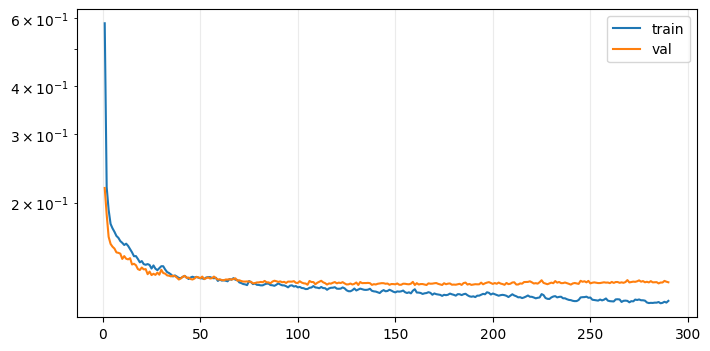

In [8]:
# Training
def run_epoch(loader,train_mode):
    model.train(train_mode)
    totals={'loss':0.0,'data':0.0,'full':0.0,'aux':0.0,'euler':0.0,'aux_cons':0.0,'alt_resid':0.0}; n=0
    for xb,yb,yfull,ab in loader:
        xb=xb.to(device); yb=yb.to(device); yfull=yfull.to(device); ab=ab.to(device)
        if train_mode: optimizer.zero_grad(set_to_none=True)
        pred_learned,alt_resid_raw,pred_aux=model(xb)
        full_raw,dh_resid=assemble_full_dx_raw(xb,pred_learned,alt_resid_raw)
        full_scaled=full_dx_scaled_from_raw(full_raw)
        data_loss=smooth_l1_weighted(pred_learned,yb,learned_weight_vec)
        full_loss=smooth_l1_weighted(full_scaled,yfull,full_weight_vec)
        aux_loss=smooth_l1_weighted(pred_aux,ab,aux_weight_vec)
        eu_loss=euler_loss(xb,full_raw)
        aux_cons=aux_consistency_loss(xb,pred_learned,ab)
        alt_resid_reg=torch.mean((dh_resid/ALT_RESIDUAL_LIMIT_M)**2)
        loss=DATA_WEIGHT*data_loss + FULL_DX_WEIGHT*full_loss + AUX_WEIGHT*aux_loss + EULER_KIN_WEIGHT*eu_loss + AUX_CONSISTENCY_WEIGHT*aux_cons + ALT_RESIDUAL_REG_WEIGHT*alt_resid_reg
        if train_mode:
            loss.backward(); nn.utils.clip_grad_norm_(model.parameters(),GRAD_CLIP); optimizer.step()
        bs=len(xb); n+=bs
        totals['loss']+=float(loss.detach().cpu())*bs; totals['data']+=float(data_loss.detach().cpu())*bs; totals['full']+=float(full_loss.detach().cpu())*bs; totals['aux']+=float(aux_loss.detach().cpu())*bs; totals['euler']+=float(eu_loss.detach().cpu())*bs; totals['aux_cons']+=float(aux_cons.detach().cpu())*bs; totals['alt_resid']+=float(alt_resid_reg.detach().cpu())*bs
    return {k:v/max(1,n) for k,v in totals.items()}

best_val=float('inf'); best_state=None; best_epoch=0; wait=0; history=[]; t0=time.time()
for epoch in range(1,EPOCHS+1):
    tr=run_epoch(train_loader,True); va=run_epoch(val_loader,False); scheduler.step()
    row={'epoch':epoch,**{f'train_{k}':v for k,v in tr.items()},**{f'val_{k}':v for k,v in va.items()},'lr':scheduler.get_last_lr()[0]}; history.append(row)
    if va['loss']<best_val:
        best_val=va['loss']; best_epoch=epoch; wait=0; best_state={k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
    else:
        wait+=1
    if epoch==1 or epoch%25==0:
        print(f"epoch {epoch:04d} train={tr['loss']:.4f} val={va['loss']:.4f} data={va['data']:.4f} full={va['full']:.4f} aux={va['aux']:.4f} alt_resid={va['alt_resid']:.4f} best={best_val:.4f}@{best_epoch}")
    if wait>=PATIENCE:
        print('early stop at',epoch,'best_epoch=',best_epoch); break
if best_state is not None: model.load_state_dict(best_state)
hist_df=pd.DataFrame(history)
print('elapsed min:',round((time.time()-t0)/60,2),'best_epoch:',best_epoch,'best_val:',best_val)
display(hist_df.tail())
fig,ax=plt.subplots(figsize=(8,4)); ax.plot(hist_df['epoch'],hist_df['train_loss'],label='train'); ax.plot(hist_df['epoch'],hist_df['val_loss'],label='val'); ax.set_yscale('log'); ax.grid(True,alpha=.25); ax.legend(); plt.show()


In [9]:
# One-step metrics
@torch.no_grad()
def predict_all(df):
    x=x_scaler.transform(df[feature_cols].to_numpy(np.float32))
    dx_parts=[]; aux_parts=[]; resid_parts=[]; model.eval()
    for i in range(0,len(x),4096):
        xb=torch.tensor(x[i:i+4096],dtype=torch.float32,device=device)
        pred_learned,alt_resid_raw,pred_aux=model(xb)
        full_raw,dh_resid=assemble_full_dx_raw(xb,pred_learned,alt_resid_raw)
        dx_parts.append(full_raw.detach().cpu().numpy())
        aux_parts.append(a_scaler.inverse_transform(pred_aux.detach().cpu().numpy()))
        resid_parts.append(dh_resid.detach().cpu().numpy())
    return np.concatenate(dx_parts), np.concatenate(aux_parts), np.concatenate(resid_parts)

def metric_table(split,cols,pred,true):
    rows=[]
    for j,c in enumerate(cols):
        err=pred[:,j]-true[:,j]
        if c=='dx_yaw_deg': err=(err+180)%360-180
        rows.append({'split':split,'target':c,'rmse':float(np.sqrt(np.mean(err**2))),'mae':float(np.mean(np.abs(err))),'std_true':float(np.std(true[:,j]))})
    return pd.DataFrame(rows)

parts=[]; aux_parts=[]; resid_rows=[]
for split,df in [('train',train_df),('val',val_df),('test',test_df),('stress',stress_test_df)]:
    if len(df)==0: continue
    pdx,paux,presid=predict_all(df)
    parts.append(metric_table(split,target_cols,pdx,df[target_cols].to_numpy(np.float32)))
    aux_parts.append(metric_table(split,aux_cols,paux,df[aux_cols].to_numpy(np.float32)))
    resid_rows.append({'split':split,'alt_resid_mean_m':float(np.mean(presid)),'alt_resid_abs_mean_m':float(np.mean(np.abs(presid))),'alt_resid_abs_max_m':float(np.max(np.abs(presid)))})
metrics_df=pd.concat(parts,ignore_index=True); aux_metrics_df=pd.concat(aux_parts,ignore_index=True); alt_residual_summary_df=pd.DataFrame(resid_rows)
print('dx metrics with kinematic altitude + bounded residual'); display(metrics_df)
print('aux metrics'); display(aux_metrics_df)
print('altitude residual usage'); display(alt_residual_summary_df)


dx metrics with kinematic altitude + bounded residual


,split,target,rmse,mae,std_true
0,train,dx_relative_altitude_m,0.005481,0.002778,0.014215
1,train,dx_vel_north_m_s,0.003495,0.001375,0.006142
2,train,dx_vel_east_m_s,0.003989,0.001644,0.006275
3,train,dx_vel_down_m_s,0.003308,0.001208,0.004371
4,train,dx_roll_deg,0.004619,0.001553,0.038966
5,train,dx_pitch_deg,0.004130,0.001324,0.036664
6,train,dx_yaw_deg,0.020040,0.005498,0.090455
7,train,dx_roll_rate_rad_s,0.001356,0.000310,0.003490
8,train,dx_pitch_rate_rad_s,0.001355,0.000309,0.003290
9,train,dx_yaw_rate_rad_s,0.000439,0.000266,0.003020


aux metrics


,split,target,rmse,mae,std_true
0,train,aux_derived_accel_north_m_s2,0.076914,0.030625,0.126517
1,train,aux_derived_accel_east_m_s2,0.089164,0.035029,0.129706
2,train,aux_derived_accel_down_m_s2,0.074987,0.026175,0.093683
3,train,aux_derived_roll_accel_rad_s2,0.036533,0.007673,0.077019
4,train,aux_derived_pitch_accel_rad_s2,0.029586,0.007101,0.064022
5,train,aux_derived_yaw_accel_rad_s2,0.011514,0.005856,0.061150
6,val,aux_derived_accel_north_m_s2,0.091262,0.029490,0.128697
7,val,aux_derived_accel_east_m_s2,0.103494,0.035664,0.141147
8,val,aux_derived_accel_down_m_s2,0.071181,0.025395,0.093486
9,val,aux_derived_roll_accel_rad_s2,0.024817,0.007355,0.065206


altitude residual usage


,split,alt_resid_mean_m,alt_resid_abs_mean_m,alt_resid_abs_max_m
0,train,0.000034,0.002188,0.008026
1,val,0.000021,0.002184,0.007106
2,test,0.000064,0.002206,0.007400
3,stress,0.005031,0.005493,0.017021


In [10]:
# Rollout sanity

def wrap_deg_np(x): return (x+180.0)%360.0-180.0

def make_feature_row(state_vec,action_vec,prev_action_vec,dt_s):
    return np.asarray(list(state_vec)+list(action_vec)+list(prev_action_vec)+list(action_vec-prev_action_vec)+[float(dt_s)],dtype=np.float32)

@torch.no_grad()
def rollout_scenario(df,scenario,max_steps=None):
    sdf=df[df['scenario'].eq(scenario)].sort_values('time_s').reset_index(drop=True)
    if max_steps is not None: sdf=sdf.iloc[:max_steps].copy()
    if len(sdf)<2: return None
    true_x=sdf[[f'x_{c}' for c in state_cols]].to_numpy(np.float32)
    true_next=sdf[[f'x_next_{c}' for c in state_cols]].to_numpy(np.float32)
    actions=sdf[[f'u_{c}' for c in action_cols]].to_numpy(np.float32)
    prev_actions=sdf[[f'prev_u_{c}' for c in action_cols]].to_numpy(np.float32)
    dts=sdf['dt_s'].to_numpy(np.float32)
    x_pred=true_x[0].copy(); prev_action=prev_actions[0].copy(); pred=[]
    for k in range(len(sdf)):
        feat=make_feature_row(x_pred,actions[k],prev_action,dts[k])
        xb=torch.tensor(x_scaler.transform(feat[None,:]),dtype=torch.float32,device=device)
        pred_learned,alt_resid_raw,_=model(xb)
        dx,_=assemble_full_dx_raw(xb,pred_learned,alt_resid_raw)
        dx=dx.detach().cpu().numpy()[0]
        x_pred=x_pred+dx
        if 'yaw_deg' in state_cols: x_pred[state_cols.index('yaw_deg')]=wrap_deg_np(x_pred[state_cols.index('yaw_deg')])
        pred.append(x_pred.copy()); prev_action=actions[k].copy()
    pred=np.asarray(pred); err=pred-true_next
    if 'yaw_deg' in state_cols:
        j=state_cols.index('yaw_deg'); err[:,j]=wrap_deg_np(err[:,j])
    rows=[]
    for j,c in enumerate(state_cols): rows.append({'scenario':scenario,'state':c,'rollout_rmse':float(np.sqrt(np.mean(err[:,j]**2))),'rollout_max_abs':float(np.max(np.abs(err[:,j]))),'steps':len(sdf)})
    return pd.DataFrame(rows),sdf,pred,true_next

rollout_metrics=[]
for split_name,df in [('test',test_df),('stress',stress_test_df)]:
    for scenario in sorted(df['scenario'].unique()) if len(df) and 'scenario' in df.columns else []:
        res=rollout_scenario(df,scenario)
        if res is not None:
            m=res[0]; m.insert(0,'split',split_name); rollout_metrics.append(m)
rollout_metrics_df=pd.concat(rollout_metrics,ignore_index=True) if rollout_metrics else pd.DataFrame()
display(rollout_metrics_df)


,split,scenario,state,rollout_rmse,rollout_max_abs,steps
0,test,N00_hover_hold_0p5192,relative_altitude_m,4.024355,9.146192,168
1,test,N00_hover_hold_0p5192,vel_north_m_s,0.194749,0.372667,168
2,test,N00_hover_hold_0p5192,vel_east_m_s,0.197010,0.562199,168
3,test,N00_hover_hold_0p5192,vel_down_m_s,0.335517,0.598875,168
4,test,N00_hover_hold_0p5192,roll_deg,0.212576,0.475575,168
...,...,...,...,...,...,...
115,stress,N11_mixed_sequence,pitch_deg,5.204176,8.924686,1445
116,stress,N11_mixed_sequence,yaw_deg,13.013592,36.265869,1445
117,stress,N11_mixed_sequence,roll_rate_rad_s,0.021145,0.066309,1445
118,stress,N11_mixed_sequence,pitch_rate_rad_s,0.023549,0.075784,1445


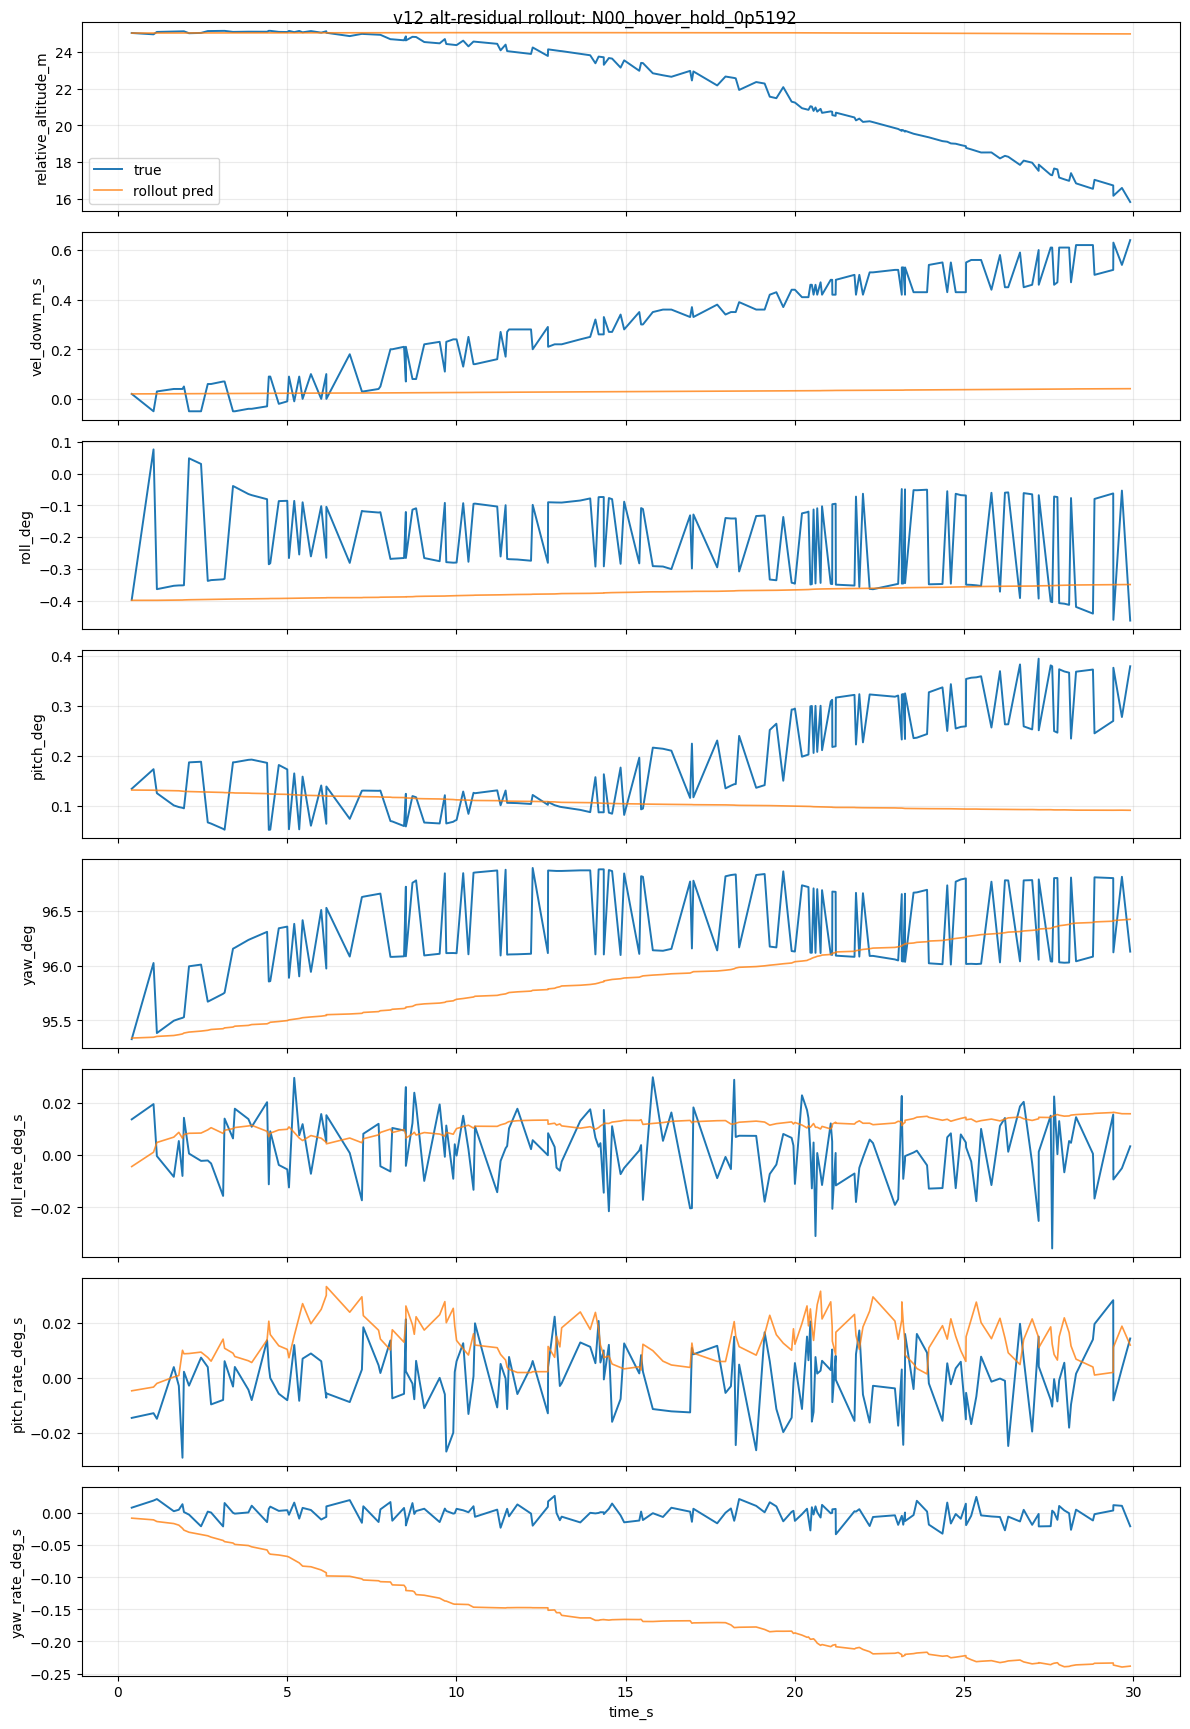

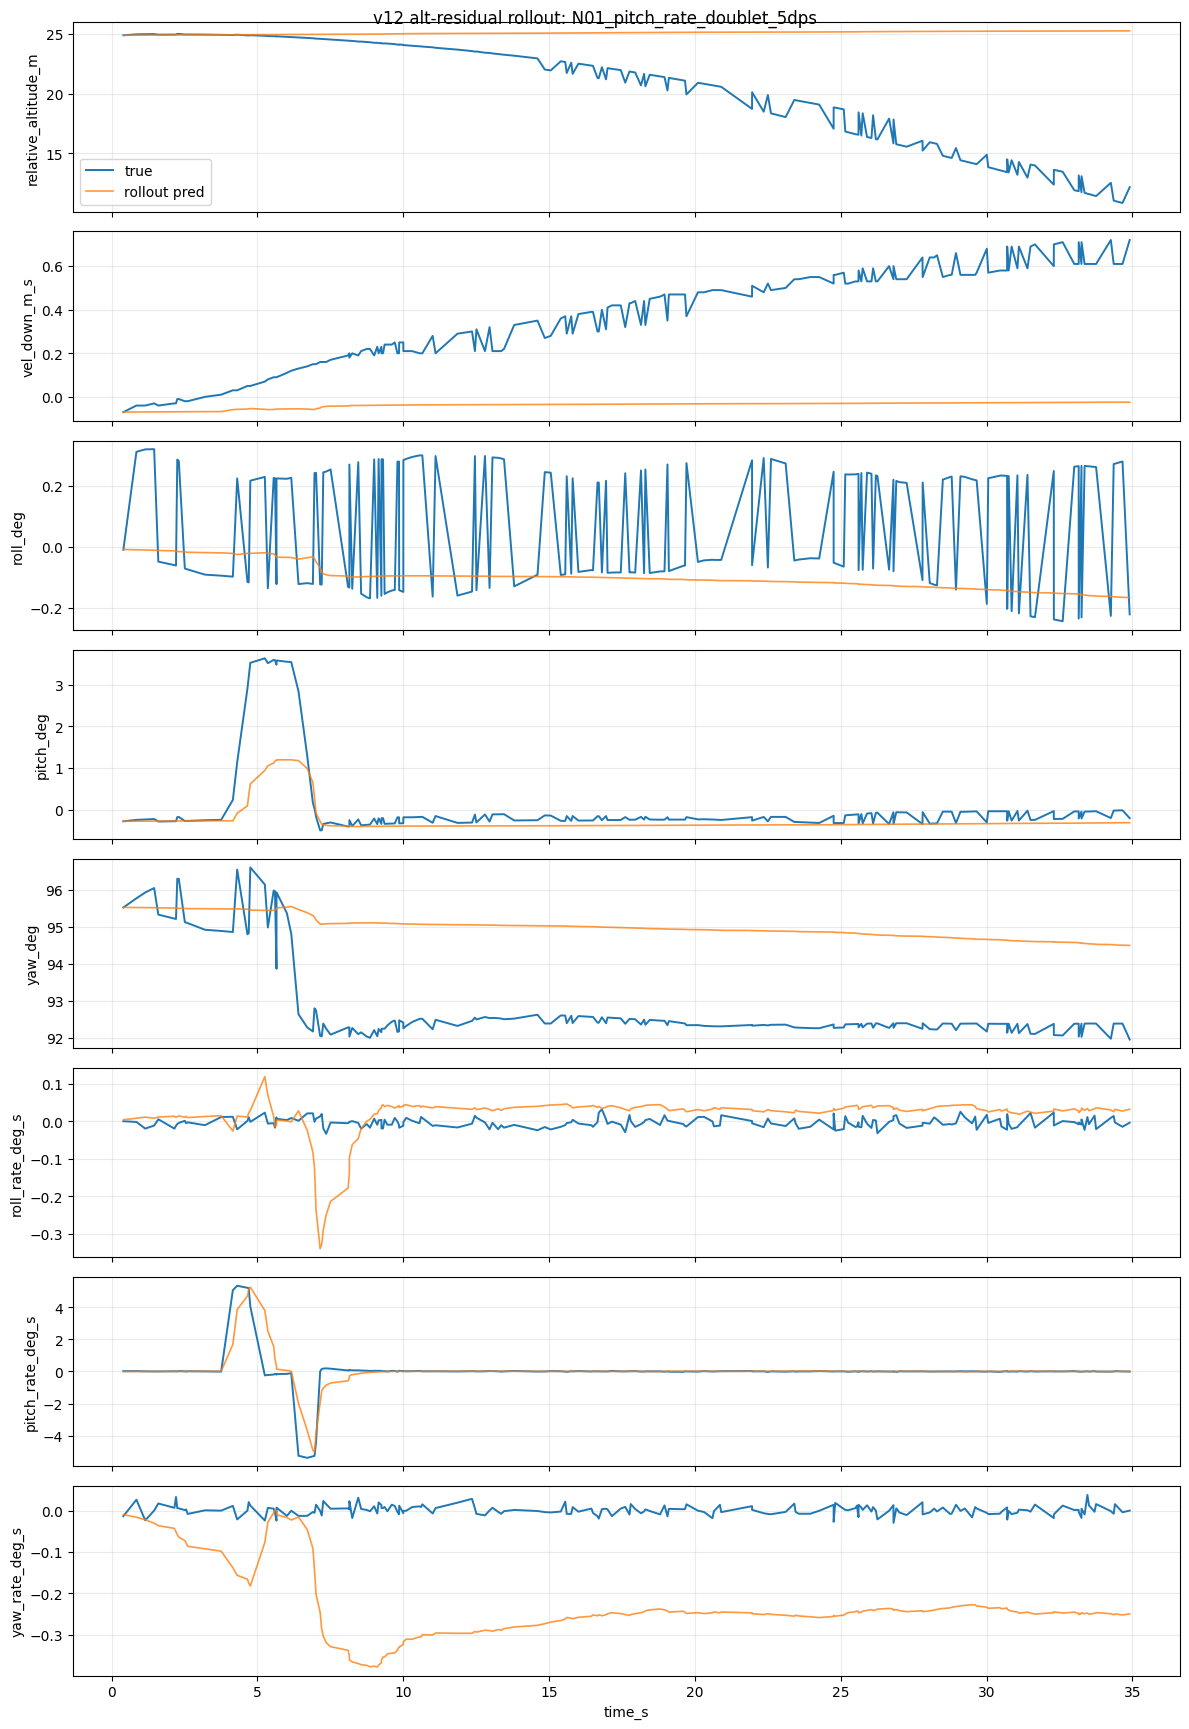

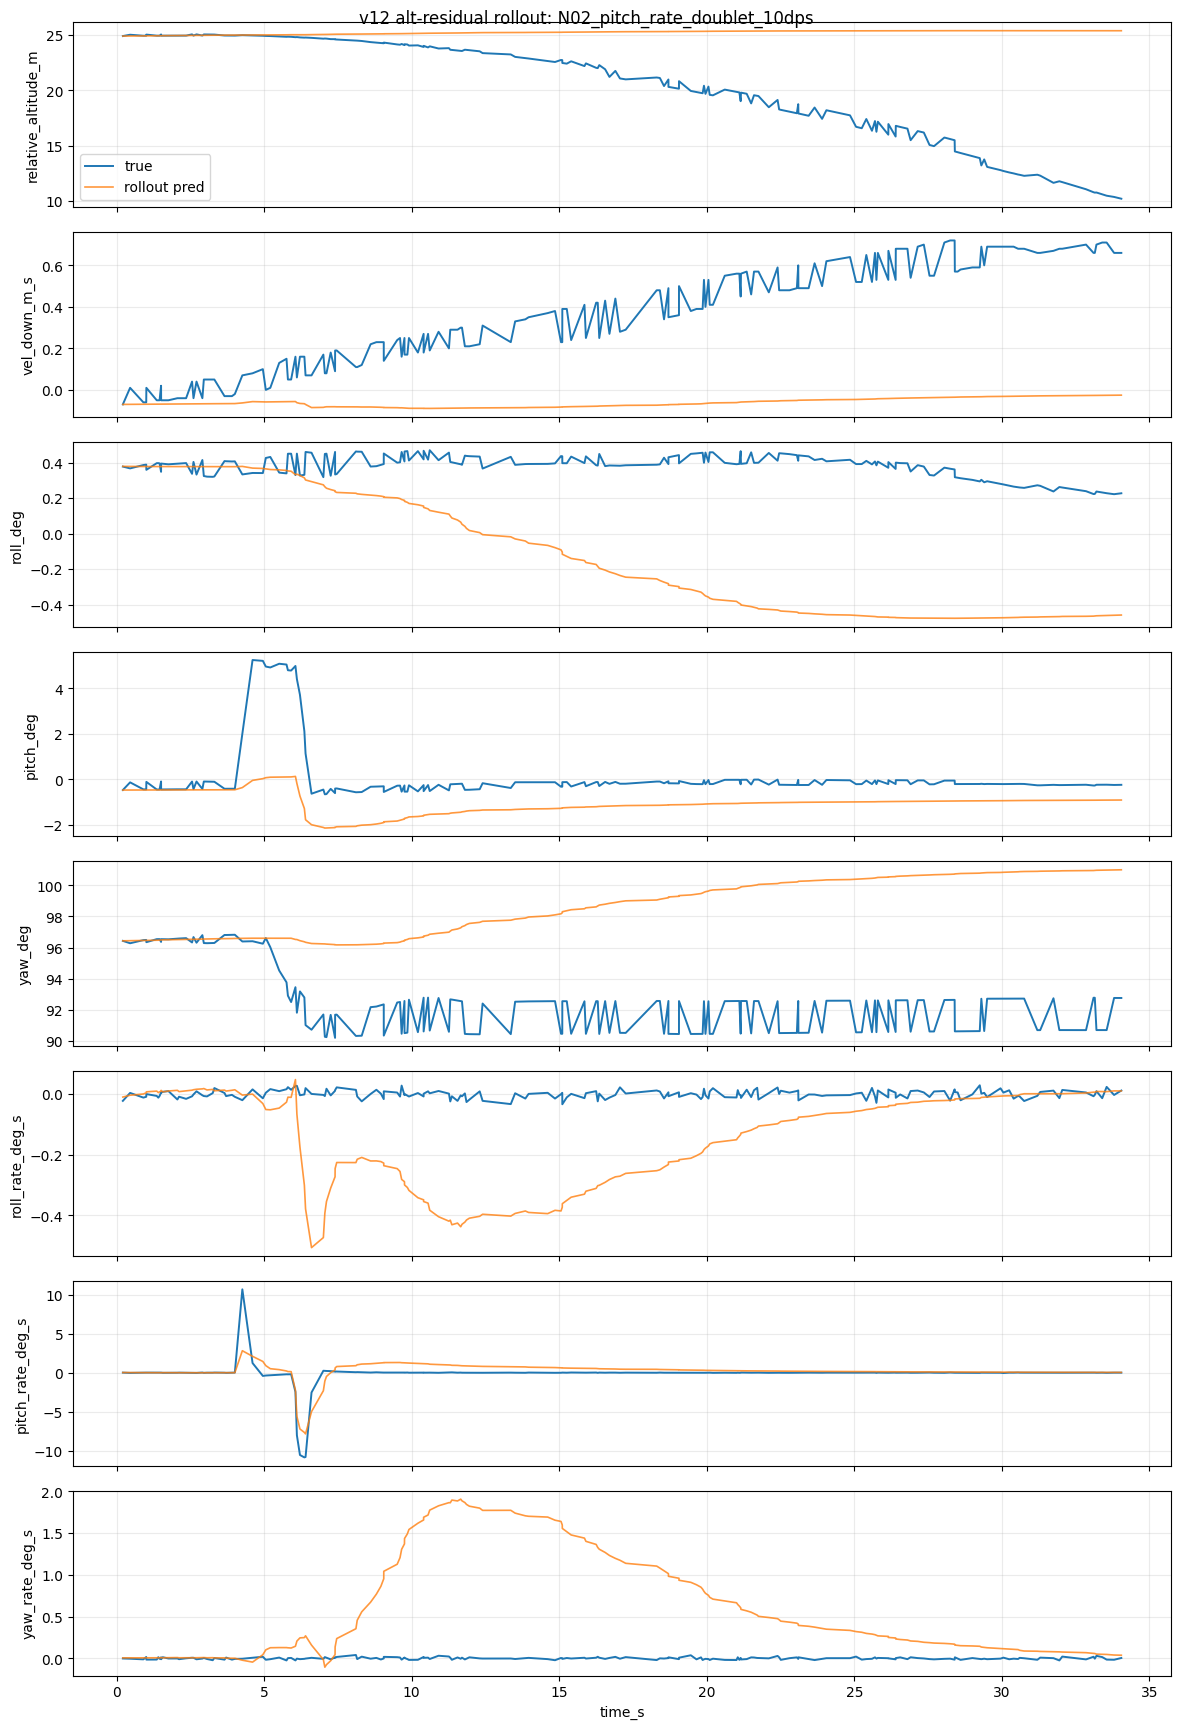

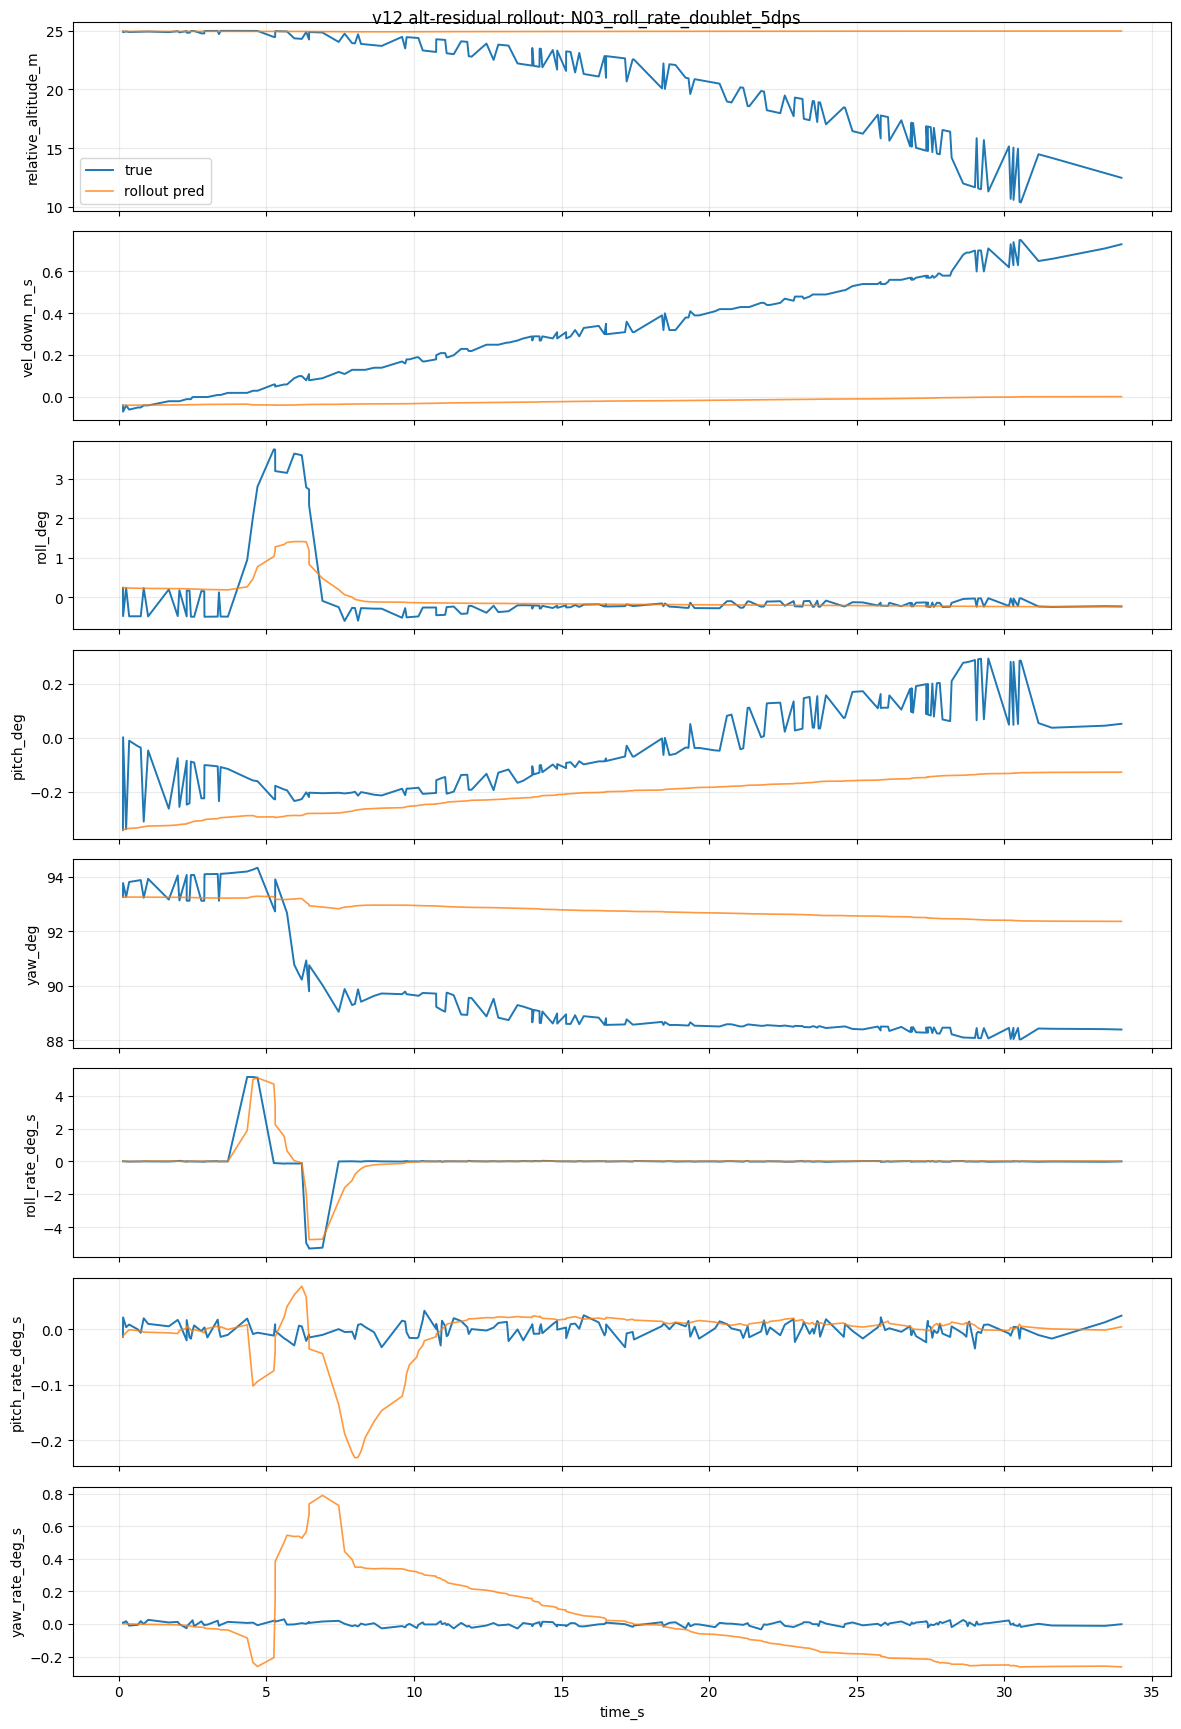

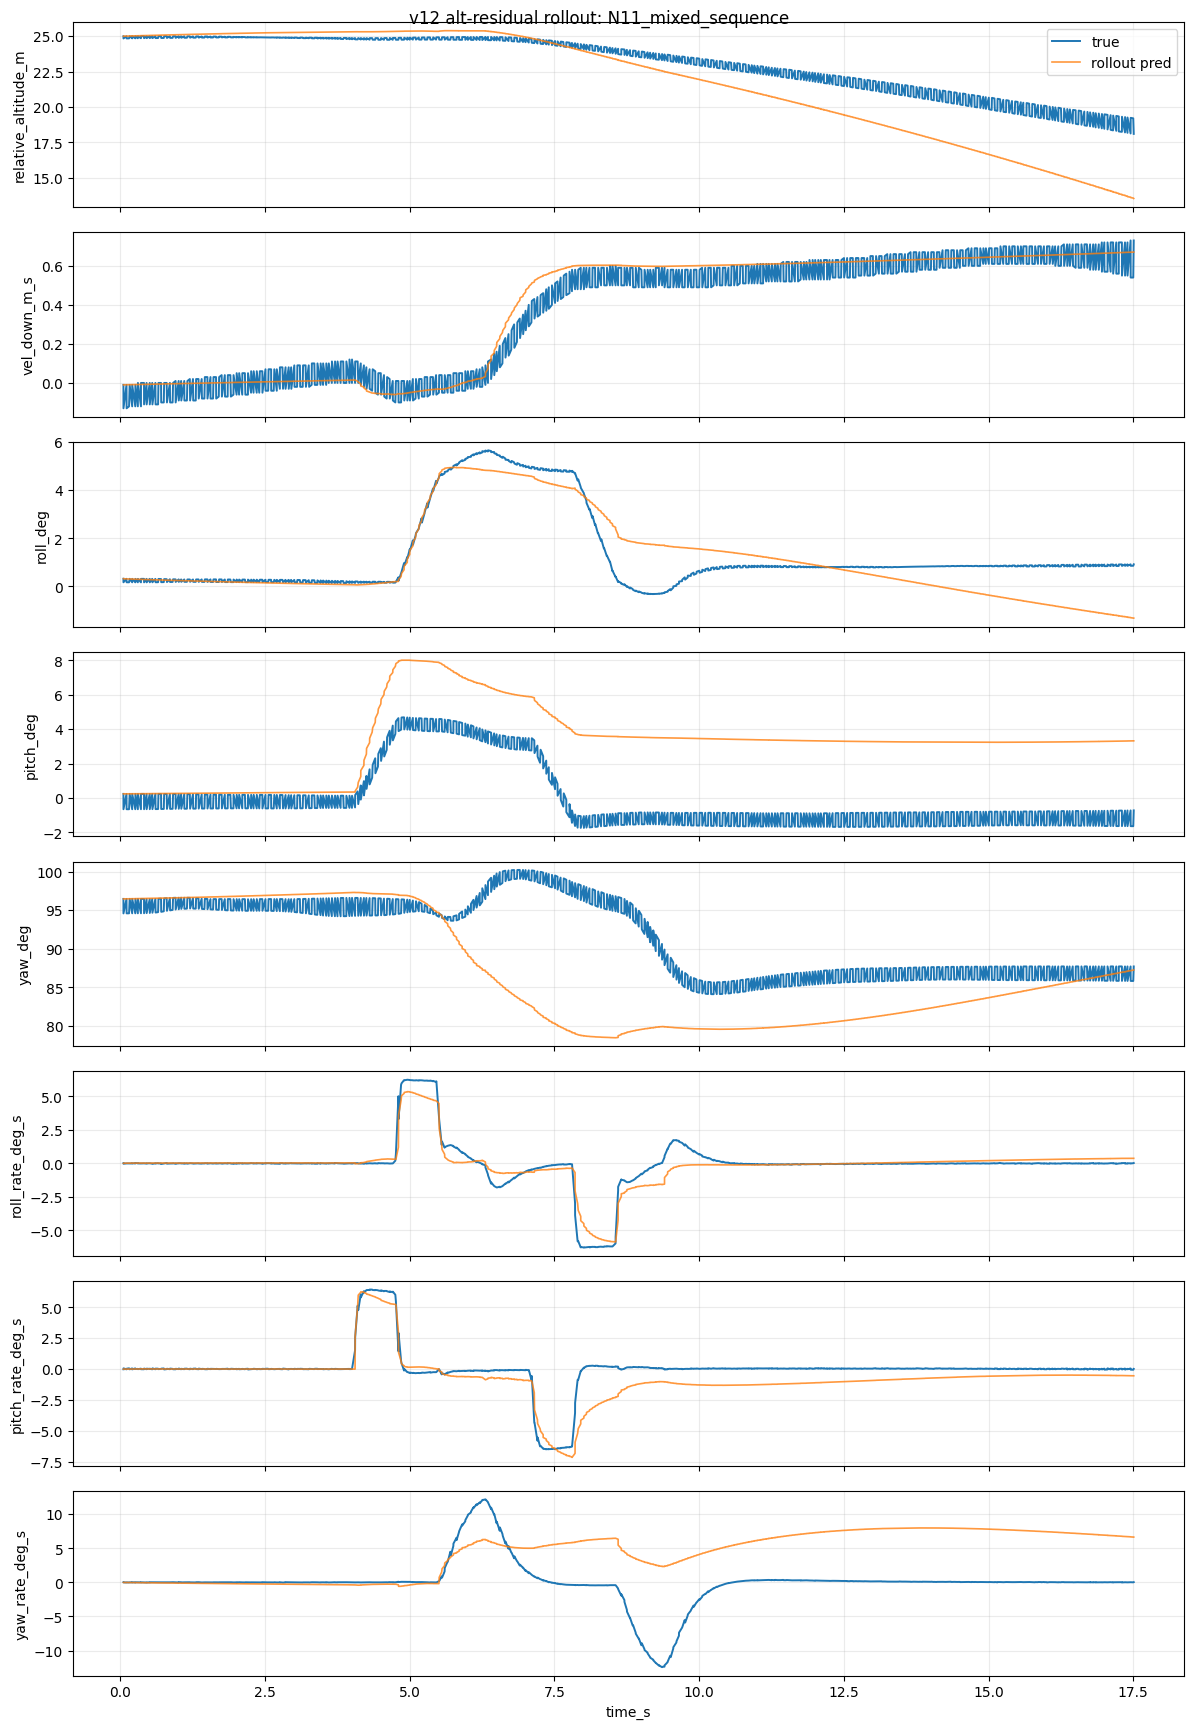

In [11]:
# Plot selected rollouts

def plot_rollout(df,scenario,max_steps=700):
    res=rollout_scenario(df,scenario,max_steps=max_steps)
    if res is None:
        print('not enough rows',scenario); return
    _,sdf,pred,true_next=res; t=sdf['time_s'].to_numpy()
    plot_states=[s for s in ['relative_altitude_m','vel_down_m_s','roll_deg','pitch_deg','yaw_deg','roll_rate_rad_s','pitch_rate_rad_s','yaw_rate_rad_s'] if s in state_cols]
    fig,axes=plt.subplots(len(plot_states),1,figsize=(12,2.2*len(plot_states)),sharex=True)
    if len(plot_states)==1: axes=[axes]
    for ax,state in zip(axes,plot_states):
        j=state_cols.index(state); yt=true_next[:,j]; yp=pred[:,j]
        label=state
        if state.endswith('_rad_s'):
            yt=np.rad2deg(yt); yp=np.rad2deg(yp); label=state.replace('_rad_s','_deg_s')
        ax.plot(t,yt,label='true',lw=1.4); ax.plot(t,yp,label='rollout pred',lw=1.2,alpha=.8); ax.set_ylabel(label); ax.grid(True,alpha=.25)
    axes[0].legend(); axes[-1].set_xlabel('time_s'); fig.suptitle(f'v12 alt-residual rollout: {scenario}'); plt.tight_layout(); plt.show()

for scenario in sorted(test_df['scenario'].unique())[:4]: plot_rollout(test_df,scenario)
if len(stress_test_df) and 'N11_mixed_sequence' in set(stress_test_df['scenario']): plot_rollout(stress_test_df,'N11_mixed_sequence')


In [12]:
# Save checkpoint
SAVE_ROOT=Path('/content/drive/MyDrive/PX4_Phase1_Models') if IN_COLAB else DATASET_PATH/'models'
SAVE_ROOT.mkdir(parents=True,exist_ok=True)
stamp=time.strftime('%Y%m%d_%H%M%S')
ckpt_path=SAVE_ROOT/f'px4_phase1_rate_dynamics_mlp_v12_alt_residual_diagnostic_{stamp}.pt'
checkpoint={
    'model_version':'px4_phase1_rate_dynamics_mlp_v12_alt_residual_diagnostic',
    'state_dict':model.state_dict(),
    'model_config':{'n_in':len(feature_cols),'n_out':len(learned_target_cols),'n_aux':len(aux_cols),**MODEL_CONFIG},
    'feature_cols':feature_cols,'target_cols':target_cols,'learned_target_cols':learned_target_cols,'aux_cols':aux_cols,'state_cols':state_cols,'action_cols':action_cols,
    'x_scaler':x_scaler.to_dict(feature_cols),'y_scaler':y_scaler.to_dict(learned_target_cols),'yfull_scaler':yfull_scaler.to_dict(target_cols),'aux_scaler':a_scaler.to_dict(aux_cols),
    'loss_config':{'data_weight':DATA_WEIGHT,'full_dx_weight':FULL_DX_WEIGHT,'aux_weight':AUX_WEIGHT,'euler_kin_weight':EULER_KIN_WEIGHT,'aux_consistency_weight':AUX_CONSISTENCY_WEIGHT,'alt_residual_reg_weight':ALT_RESIDUAL_REG_WEIGHT,'alt_residual_limit_m':ALT_RESIDUAL_LIMIT_M,'stress_scenarios':STRESS_SCENARIOS,'altitude_update':'kinematic_from_predicted_dx_vel_down_plus_bounded_residual'},
    'dataset_path':str(DATASET_PATH),'metadata':metadata,'hover_diagnostics':hover_diag.to_dict(orient='records'),'kinematic_diagnostics':kin_diag.to_dict(orient='records'),'history':hist_df.to_dict(orient='records'),'one_step_metrics':metrics_df.to_dict(orient='records'),'aux_metrics':aux_metrics_df.to_dict(orient='records'),'alt_residual_summary':alt_residual_summary_df.to_dict(orient='records'),'rollout_metrics':rollout_metrics_df.to_dict(orient='records')
}
torch.save(checkpoint,ckpt_path)
print('saved:',ckpt_path)


saved: /content/drive/MyDrive/PX4_Phase1_Models/px4_phase1_rate_dynamics_mlp_v12_alt_residual_diagnostic_20260508_093347.pt


In [13]:
# Minimal load check
loaded=torch.load(ckpt_path,map_location='cpu')
print('loaded keys:',sorted(loaded.keys()))
print('feature/learned_target/full_target/aux:',len(loaded['feature_cols']),len(loaded['learned_target_cols']),len(loaded['target_cols']),len(loaded['aux_cols']))


loaded keys: ['action_cols', 'alt_residual_summary', 'aux_cols', 'aux_metrics', 'aux_scaler', 'dataset_path', 'feature_cols', 'history', 'hover_diagnostics', 'kinematic_diagnostics', 'learned_target_cols', 'loss_config', 'metadata', 'model_config', 'model_version', 'one_step_metrics', 'rollout_metrics', 'state_cols', 'state_dict', 'target_cols', 'x_scaler', 'y_scaler', 'yfull_scaler']
feature/learned_target/full_target/aux: 23 9 10 6
